# LoRA Fine-Tuning with Hugging Face and TensorFlow on ProsusAI/finbert

## 1. Importing required libraries

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EvalPrediction
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Loading the dataset

In [5]:
df = pd.read_csv('../data/processed/financial_news_balanced.csv')


## 3. Define Split Strategy and Prepare Data

In [6]:
# Define split ratios for training and validation only
# - 80% for training
# - 20% for validation
TRAIN_SIZE = 0.80    
VAL_SIZE = 0.20      

# Prepare features and labels
X = df['text']
y = df['target_sentiment']

# Create label mappings
labels = ['positive', 'negative', 'neutral']
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

# Convert string labels to integers
y_encoded = y.map(label2id)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=VAL_SIZE,
    stratify=y_encoded,
    random_state=42
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")

Training set: 9418 samples (80.0%)
Validation set: 2355 samples (20.0%)


## 4. Preprocess the dataset for input into the model

In [7]:
model_name = "ProsusAI/finbert"

# Convert splits to Hugging Face Dataset objects
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply tokenization to the datasets
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)


Map: 100%|██████████| 2355/2355 [00:00<00:00, 12270.61 examples/s]


## 5. Loading and applying LoRA to the model

In [8]:
# Create LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence Classification
    r=4,                        # Rank of the update matrices
    lora_alpha=32,              # Alpha parameter for scaling
    lora_dropout=0.1,           # Dropout probability
    bias="none",                # No bias training
    target_modules=["query", "key", "value"] # Target modules to apply LoRA
)

# Applies LoRA to the model
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 223,491 || all params: 109,708,038 || trainable%: 0.2037


## 6. Training the model

In [9]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="../tests/model_training_out/finbert-lora",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",    
    load_best_model_at_end=True,
    push_to_hub=False, 
)

# Define a function to compute metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

# Create Trainer instance
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Train the model
print("Starting training...")
trainer.train()
print("Training finished.")

C:\Users\eucli\AppData\Local\Temp\ipykernel_19100\2771576088.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting training...


c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.013900,0.977068,0.481529,0.427701
2,0.971800,0.935467,0.521868,0.516076
3,0.964400,0.928610,0.528662,0.515707


c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training finished.


## 7. Evaluating the Model

In [ ]:
# Evaluating the trainer
eval_results = trainer.evaluate()
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print("\n--- Evaluation Results ---")
for key, value in eval_results.items():
    print(f"{key}: {value}")

Trainer evaluate:


c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Validation Accuracy: 0.5287

--- Evaluation Results ---
eval_loss: 0.92861008644104
eval_accuracy: 0.5286624203821656
eval_f1: 0.51570739941862
eval_runtime: 451.3573
eval_samples_per_second: 5.218
eval_steps_per_second: 0.654
epoch: 3.0


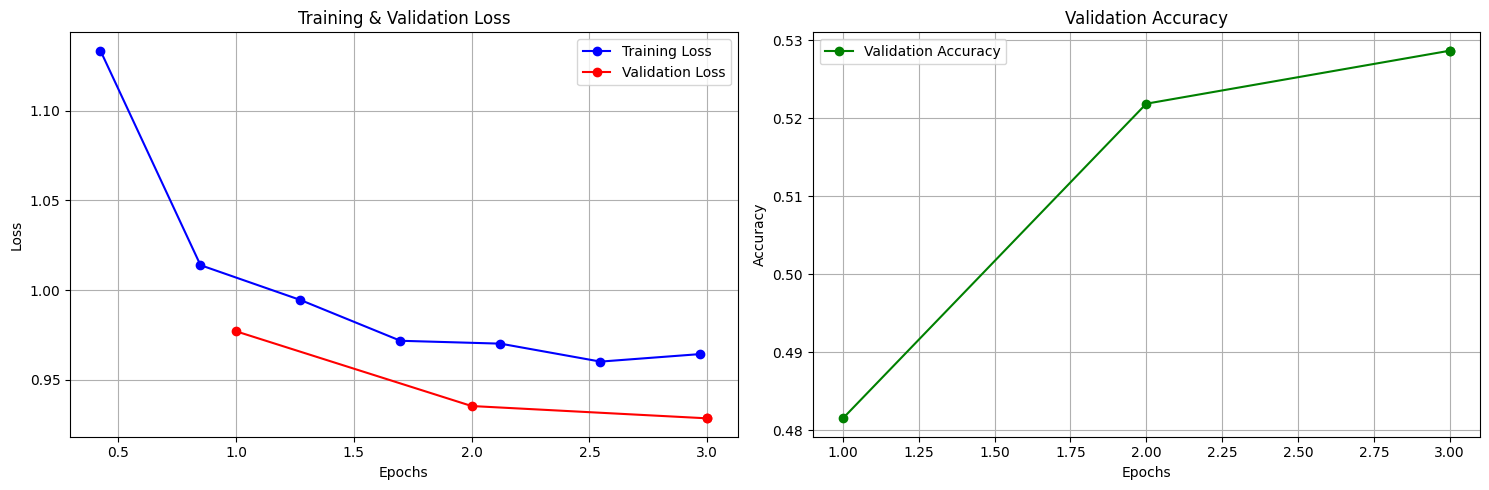

In [12]:
# Plotting Loss and Accuracy Curves
# Extracting history
log_history = trainer.state.log_history
# Get training and evaluation logs 
train_logs = [log for log in log_history if 'loss' in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]
# Extract data for plotting
train_epochs = [log['epoch'] for log in train_logs]
train_loss = [log['loss'] for log in train_logs]
eval_epochs = [log['epoch'] for log in eval_logs]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]
# Setting the figure for plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Plotting training and validation loss
ax1.plot(train_epochs, train_loss, 'b-o', label='Training Loss')
ax1.plot(eval_epochs, eval_loss, 'r-o', label='Validation Loss')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)
# Plotting validation accuracy
ax2.plot(eval_epochs, eval_accuracy, 'g-o', label='Validation Accuracy')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


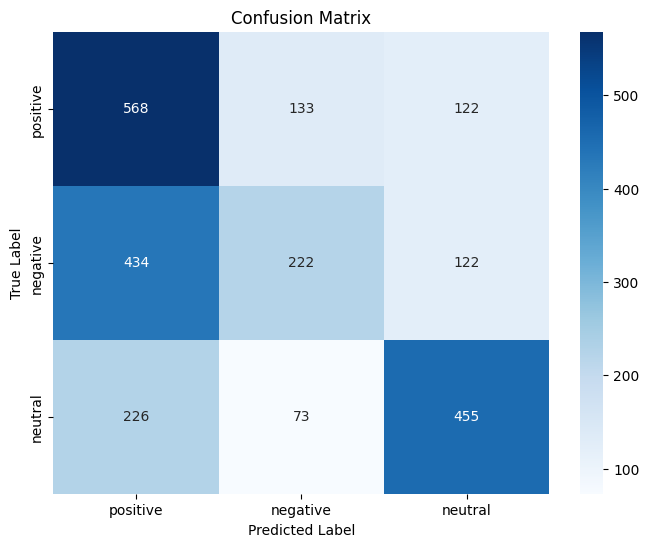

In [ ]:
# Plotting Confusion Matrix
predictions = trainer.predict(tokenized_val_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)
actual_labels = y_val.to_numpy()
cm = confusion_matrix(actual_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
# Displaying Classification Report
report = classification_report(actual_labels, predicted_labels, target_names=labels, output_dict=True)
print(classification_report(actual_labels, predicted_labels, target_names=labels))

              precision    recall  f1-score   support

    positive       0.46      0.69      0.55       823
    negative       0.52      0.29      0.37       778
     neutral       0.65      0.60      0.63       754

    accuracy                           0.53      2355
   macro avg       0.54      0.53      0.52      2355
weighted avg       0.54      0.53      0.52      2355



## Saving the model

In [ ]:
trainer.save_model("../src/llm/finbert-lora-spanish")
print("Model saved!")